<a href="https://colab.research.google.com/github/shakhawat17/Data-Science/blob/main/Shakhawat_Machine_Learning_Cybersecurity_Phishing_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning in Cybersecurity — Phishing Website Classification

**Homework:** Exploratory Data Analysis, Feature Engineering, and Machine Learning  
**Dataset:** UCI-style Phishing Websites Features (`Training Dataset.arff`)  
**Models:** Decision Tree, Random Forest, SVM, Neural Network




In [15]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from google.colab import files
    if not os.path.exists("Training Dataset.arff"):
        uploaded = files.upload()
except ImportError:
    pass

ARFF_PATH = "Training Dataset.arff"
print("Dataset path:", ARFF_PATH)


Dataset path: Training Dataset.arff


In [16]:

from scipy.io import arff

data, meta = arff.loadarff(ARFF_PATH)
df = pd.DataFrame(data)


for col in df.columns:
    df[col] = df[col].astype(str).str.strip().str.strip("'")

print("Dataset shape:", df.shape)
display(df.head())
print("\nColumn names:")
print(df.columns.tolist())


Dataset shape: (11055, 31)


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1



Column names:
['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']


## 1. Exploratory Data Analysis


In [17]:

missing = df.isnull().sum()
missing_total = int(missing.sum())

print("Total missing values:", missing_total)
display(missing[missing > 0].to_frame("Missing Values"))


for marker in ["?", "", "nan", "None"]:
    print(f"Marker '{marker}':", (df == marker).sum().sum())


Total missing values: 0


,Missing Values


Marker '?': 0
Marker '': 0
Marker 'nan': 0
Marker 'None': 0


Class counts:


,count
Result,
1,6157
-1,4898



Class percentages:


,proportion
Result,
1,55.69
-1,44.31


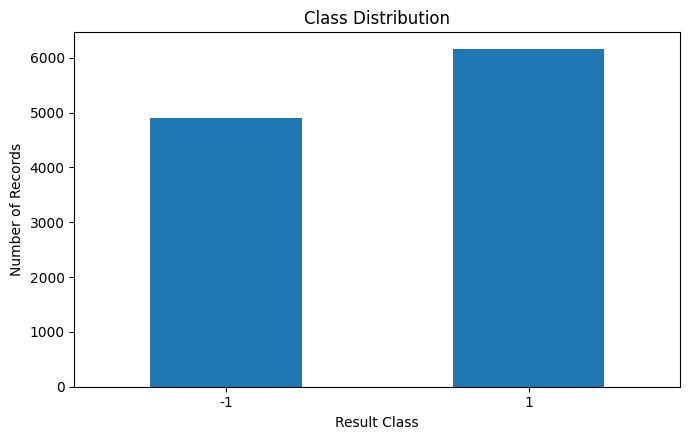

In [18]:
# Class distribution
print("Class counts:")
display(df["Result"].value_counts())

class_pct = df["Result"].value_counts(normalize=True).mul(100).round(2)
print("\nClass percentages:")
display(class_pct)

plt.figure(figsize=(7,4.5))
df["Result"].value_counts().sort_index().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Result Class")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [19]:
# Basic dataset statistics and duplicate check
print("Duplicate rows:", df.duplicated().sum())
display(df.describe(include="all").T)


Duplicate rows: 5206


,count,unique,top,freq
having_IP_Address,11055,2,1,7262
URL_Length,11055,3,-1,8960
Shortining_Service,11055,2,1,9611
having_At_Symbol,11055,2,1,9400
double_slash_redirecting,11055,2,1,9626
Prefix_Suffix,11055,2,-1,9590
having_Sub_Domain,11055,3,1,4070
SSLfinal_State,11055,3,1,6331
Domain_registeration_length,11055,2,-1,7389
Favicon,11055,2,1,9002


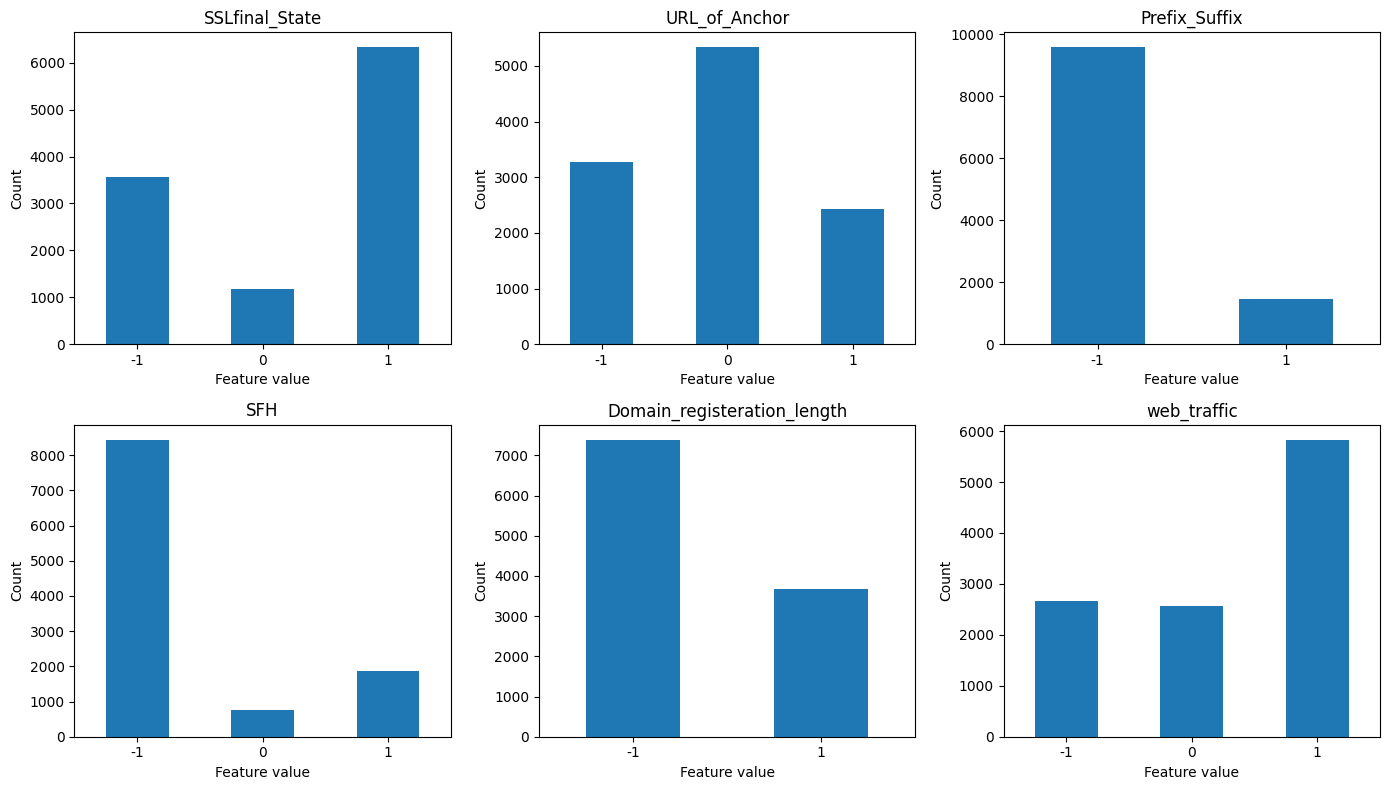

In [20]:
# Visualize selected/key feature distributions
key_features = [
    "SSLfinal_State", "URL_of_Anchor", "Prefix_Suffix",
    "SFH", "Domain_registeration_length", "web_traffic"
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), key_features):
    df[col].value_counts().sort_index().plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Feature value")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


## 2. Numerical Conversion and Train/Test Split


In [21]:
# Convert feature category codes to integers
feature_cols = [c for c in df.columns if c != "Result"]

for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Result"] = df["Result"].map({"-1": 0, "1": 1}).astype(int)

X = df[feature_cols].copy()
y = df["Result"].copy()

print("Feature matrix:", X.shape)
print("Target distribution:")
display(y.value_counts())


Feature matrix: (11055, 30)
Target distribution:


,count
Result,
1,6157
0,4898


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training proportion:", round(len(X_train)/len(X)*100, 2), "%")
print("Testing proportion:", round(len(X_test)/len(X)*100, 2), "%")


Training samples: 8844
Testing samples: 2211
Training proportion: 80.0 %
Testing proportion: 20.0 %


## 3. Chi-Square Feature Selection


Selected features:
['SSLfinal_State', 'URL_of_Anchor', 'Prefix_Suffix', 'SFH', 'Domain_registeration_length', 'web_traffic', 'having_Sub_Domain', 'Request_URL', 'Links_in_tags', 'Page_Rank', 'age_of_domain', 'having_IP_Address', 'URL_Length', 'DNSRecord', 'Google_Index', 'Statistical_report', 'Shortining_Service', 'having_At_Symbol', 'Redirect', 'Abnormal_URL']


,Feature,Chi2 Score,P-value
7,SSLfinal_State,1511.147203,0.000000e+00
13,URL_of_Anchor,1184.091150,1.748861e-259
5,Prefix_Suffix,932.175396,9.940570e-205
15,SFH,304.510196,3.429064e-68
8,Domain_registeration_length,289.443802,6.572751e-65
25,web_traffic,282.958621,1.701662e-63
6,having_Sub_Domain,251.044348,1.537320e-56
12,Request_URL,224.433867,9.756341e-51
14,Links_in_tags,177.247610,1.933765e-40
26,Page_Rank,79.068139,6.000425e-19


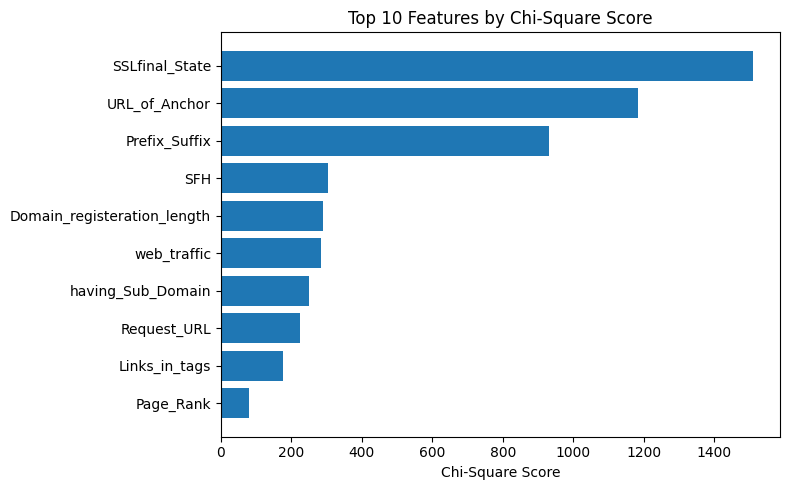

In [23]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2

# Scale only for the Chi-Square calculation
chi_scaler = MinMaxScaler()
X_train_nonnegative = chi_scaler.fit_transform(X_train)
X_test_nonnegative = chi_scaler.transform(X_test)

selector = SelectKBest(score_func=chi2, k=20)
X_train_selected = selector.fit_transform(X_train_nonnegative, y_train)
X_test_selected = selector.transform(X_test_nonnegative)

chi_table = pd.DataFrame({
    "Feature": feature_cols,
    "Chi2 Score": selector.scores_,
    "P-value": selector.pvalues_
}).sort_values("Chi2 Score", ascending=False)

selected_features = chi_table.head(20)["Feature"].tolist()

print("Selected features:")
print(selected_features)
display(chi_table)

plt.figure(figsize=(8,5))
top10 = chi_table.head(10).sort_values("Chi2 Score")
plt.barh(top10["Feature"], top10["Chi2 Score"])
plt.title("Top 10 Features by Chi-Square Score")
plt.xlabel("Chi-Square Score")
plt.tight_layout()
plt.show()


## 4. Train Four Machine-Learning Models


In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import time

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", random_state=42))
    ]),
    "Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            early_stopping=True,
            random_state=42
        ))
    ])
}

results = []
confusion_matrices = {}
trained_models = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train_selected, y_train)
    predictions = model.predict(X_test_selected)
    elapsed = time.time() - start

    trained_models[name] = model
    cm = confusion_matrix(y_test, predictions)
    confusion_matrices[name] = cm

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1-Score": f1_score(y_test, predictions),
        "Training Time (s)": elapsed
    })

results_df = pd.DataFrame(results)
display(results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "Training Time (s)": "{:.3f}"
}))


,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s)
0,Decision Tree,0.9656,0.9684,0.9699,0.9692,0.017
1,Random Forest,0.9706,0.9724,0.9748,0.9736,1.055
2,SVM,0.9471,0.9365,0.9708,0.9533,1.416
3,Neural Network,0.9629,0.9622,0.9716,0.9669,4.029


In [25]:
# Detailed classification reports
for name, model in trained_models.items():
    predictions = model.predict(X_test_selected)
    print("=" * 70)
    print(name)
    print(classification_report(
        y_test,
        predictions,
        target_names=["Phishing", "Legitimate"],
        digits=4
    ))


Decision Tree
              precision    recall  f1-score   support

    Phishing     0.9622    0.9602    0.9612       980
  Legitimate     0.9684    0.9699    0.9692      1231

    accuracy                         0.9656      2211
   macro avg     0.9653    0.9651    0.9652      2211
weighted avg     0.9656    0.9656    0.9656      2211

Random Forest
              precision    recall  f1-score   support

    Phishing     0.9683    0.9653    0.9668       980
  Legitimate     0.9724    0.9748    0.9736      1231

    accuracy                         0.9706      2211
   macro avg     0.9704    0.9701    0.9702      2211
weighted avg     0.9706    0.9706    0.9706      2211

SVM
              precision    recall  f1-score   support

    Phishing     0.9615    0.9173    0.9389       980
  Legitimate     0.9365    0.9708    0.9533      1231

    accuracy                         0.9471      2211
   macro avg     0.9490    0.9441    0.9461      2211
weighted avg     0.9476    0.9471    0.946

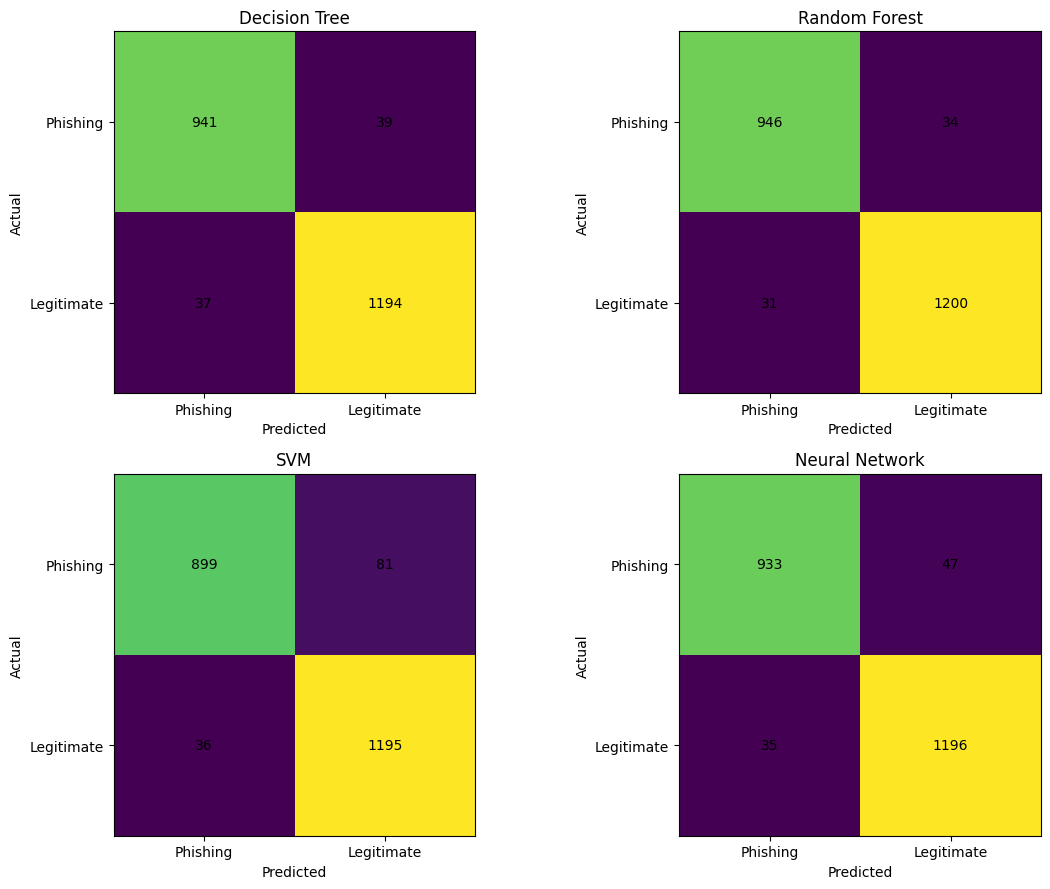

In [26]:
# Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, (name, cm) in zip(axes.ravel(), confusion_matrices.items()):
    im = ax.imshow(cm)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1], ["Phishing", "Legitimate"])
    ax.set_yticks([0, 1], ["Phishing", "Legitimate"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


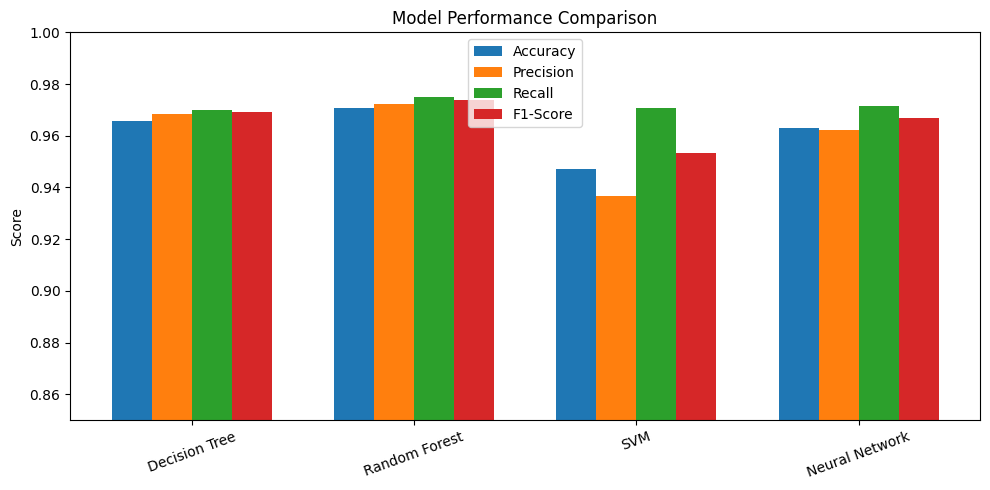

In [27]:
# Model comparison graph
plt.figure(figsize=(10,5))
x = np.arange(len(results_df))
width = 0.18

for i, metric in enumerate(["Accuracy", "Precision", "Recall", "F1-Score"]):
    plt.bar(x + (i - 1.5) * width, results_df[metric], width, label=metric)

plt.xticks(x, results_df["Model"], rotation=20)
plt.ylim(0.85, 1.0)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Results and Discussion

Using the required stratified 80/20 split and the top 20 Chi-Square-selected features, all four models achieve high test-set performance.

The Random Forest obtains the highest accuracy and F1-score in this run. The Decision Tree and Neural Network are also strong, while the SVM has the lowest accuracy among the four models in this particular configuration.

The confusion matrices should be considered together with precision and recall because phishing detection is a binary classification problem where both false positives and false negatives matter.

**Important limitation:** the provided dataset contains many exact duplicate rows. The required random split was used without removing duplicates so that the supplied dataset is analyzed as provided. Consequently, duplicate records can occur across training and testing sets and may make the reported scores more optimistic than a duplicate-grouped evaluation.


In [28]:

results_df.to_csv("model_results.csv", index=False)
chi_table.to_csv("chi_square_feature_scores.csv", index=False)

print("Saved:")
print("- model_results.csv")
print("- chi_square_feature_scores.csv")


Saved:
- model_results.csv
- chi_square_feature_scores.csv


## 6. Conclusion

The experiment demonstrates a complete phishing-website classification workflow: EDA, numerical conversion, Chi-Square feature selection, stratified train/test splitting, training of four models, and evaluation using accuracy, precision, recall, F1-score, and confusion matrices.

For this dataset and this fixed split, Random Forest produced the strongest overall test metrics. However, model performance should not be generalized beyond this dataset without further validation, especially because duplicate records are present.

**Reference material:** Mohammad, Thabtah and McCluskey, *Phishing Websites Features*.
